# Absorption Coefficient Analytical Calculation

In [1]:
#  imports
from IPython.display import Markdown, display
import numpy as np
import matplotlib.pyplot as plt

## Constants

In [2]:
# --- Physical constants ---
h = 6.62607015e-34        # Planck constant, J·s
k_B = 1.380649e-23        # Boltzmann constant, J/K
c = 299792458.0           # Speed of light, m/s
amu = 1.66053906660e-27   # Atomic mass unit, kg

# --- Transition parameters ---
f_S12_to_P12 = 377.107463380e12        # Hz
f_S12F1_to_S12 = 4.271676631815181e9  # Hz
f_S12F1_to_S12F2 = 6.834682610904290e9  # Hz
f_P12F1_to_P12 = 509.06e6           # Hz
f_p12F1_to_P12F2 = 814.5e6          # Hz

f_S12_to_P32 = 384.2304844685e12
# f_S12F1_to_S12 = 4.271676631815181e9
f_P32F0_to_P32 = 302.0738e6
f_P32F0_to_P32F1 = 72.2180e6
f_P32F1_to_P32F2 = 156.9470e6
f_P32F2_to_P32F3 = 266.6500e6

# note that D1x is the transition from S1/2 F=1 to P1/2 F'=x
# and D2x is the transition from S1/2 F=1 to P3/2 F'=x

# Central transition frequency: S1/2 F=1 → P1/2 F'=1
f_D11 = f_S12_to_P12 + f_S12F1_to_S12 - f_P12F1_to_P12
f_D12 = f_D11 + f_p12F1_to_P12F2
f_D20 = f_S12_to_P32 + f_S12F1_to_S12 - f_P32F0_to_P32
f_D21 = f_D20 + f_P32F0_to_P32F1
f_D22 = f_D21 + f_P32F1_to_P32F2
f_D23 = f_D22 + f_P32F2_to_P32F3

# all the f_d can be found using f_d = f_0 - delta_f_d
# delta_f_d = f_S12F1_to_S12F2

# Wavelength
lambda_D11 = c / f_D11
lambda_D12 = c / f_D12
lambda_D20 = c / f_D20
lambda_D21 = c / f_D21
lambda_D22 = c / f_D22
lambda_D23 = c / f_D23


# Linewidth (Γ_D1)
Gamma_D2 = 6.0666e6  # Hz
Gamma_D1 = 5.7500e6  # Hz

# Gamma ratio S_ij of de-excitation from i to j
S_D1_22 = 1/2
S_D1_21 = 1/2
S_D1_12 = 5/6
S_D1_11 = 1/6

S_D2_32 = 1
S_D2_22 = 1/2
S_D2_21 = 1/2
S_D2_12 = 1/6
S_D2_11 = 5/6
S_D2_01 = 1

# in the ideal case (experiment values are a bit different)
S_D11 = S_D1_11
S_D12 = S_D1_21
S_D11_d = S_D1_12
S_D12_d = S_D1_22

S_D20 = S_D2_01
S_D21 = S_D2_11
S_D22 = S_D2_21
S_D23 = 0
S_D20_d = 0
S_D21_d = S_D2_12
S_D22_d = S_D2_22
S_D23_d = S_D2_32

# so each linewidth is scaled by the line strength 
Gamma_D11 = S_D11 * Gamma_D1
Gamma_D12 = S_D12 * Gamma_D1
Gamma_D11_d = S_D11_d * Gamma_D1 
Gamma_D12_d = S_D12_d * Gamma_D1 

Gamma_D20 = S_D20 * Gamma_D2 
Gamma_D21 = S_D21 * Gamma_D2  
Gamma_D22 = S_D22 * Gamma_D2
Gamma_D23 = S_D23 * Gamma_D2
Gamma_D20_d = S_D20_d * Gamma_D2
Gamma_D21_d = S_D21_d * Gamma_D2
Gamma_D22_d = S_D22_d * Gamma_D2
Gamma_D23_d = S_D23_d * Gamma_D2

# line strength ratio S_ij coefficients for Einstein B calculation with ground i and excited j
S_coeff_D1_22 = 1/2
S_coeff_D1_21 = 1/2
S_coeff_D1_12 = 5/6
S_coeff_D1_11 = 1/6

S_coeff_D2_23 = 7/10
S_coeff_D2_22 = 1/4
S_coeff_D2_21 = 1/20
S_coeff_D2_12 = 5/12
S_coeff_D2_11 = 5/12
S_coeff_D2_10 = 1/6


# Peak cross-section (sigma_0)
# devided by 3 to account for averaging over polarizations
sigma_D11_0 = 3 * lambda_D11**2 / (2 * np.pi) /3
sigma_D12_0 = 3 * lambda_D12**2 / (2 * np.pi) /3

sigma_D20_0 = 3 * lambda_D20**2 / (2 * np.pi) /3
sigma_D21_0 = 3 * lambda_D21**2 / (2 * np.pi) /3
sigma_D22_0 = 3 * lambda_D22**2 / (2 * np.pi) /3
sigma_D23_0 = 3 * lambda_D23**2 / (2 * np.pi) /3

# Rubidium-87 mass
m_Rb87 = 86.909180527 * amu

# Temperature and Doppler parameter
T = 300.0  # K
u = np.sqrt(2 * k_B * T / m_Rb87)

# Rb vapor number density (low-pressure) (assumed)
T = 273.15 + 30 # K
if(T < 273.15 + 39.31): # is solid
    log10_P_Torr = -94.04826 -1961.258 / T - 0.03771687 * T + 42.57526 * np.log10(T)
else:
    log10_P_Torr = 15.88253 - 4529.635 / T + 5.8663e-4 * T - 2.99138 * np.log10(T)
P_Torr = 10**log10_P_Torr
P_Pa = P_Torr * 133.322368  # Pa
N = 0.2783 * P_Pa / (k_B * T)  # ideal gas law, m^-3
print(f"Rb-87 vapor number density N = {N/1e16:.2f} x10^16 m^-3 at T = {T:.2f} K")

# Saturation and pump intensities
I_sat_D11 = h * f_D11 * Gamma_D1 / (2 * sigma_D11_0)
I_sat_D12 = h * f_D12 * Gamma_D1 / (2 * sigma_D12_0)
I_pu_D1 = I_sat_D11  # set equal I_sat_D11
print(f"I_pu_D1 = {I_pu_D1/10:.2f} mW/cm^2 I_sat_D11 = {I_sat_D11/10:.2f} mW/cm^2")

I_sat_D20 = h * f_D20 * Gamma_D2 / (2 * sigma_D20_0)
I_sat_D21 = h * f_D21 * Gamma_D2 / (2 * sigma_D21_0)
I_sat_D22 = h * f_D22 * Gamma_D2 / (2 * sigma_D22_0)
I_sat_D23 = h * f_D23 * Gamma_D2 / (2 * sigma_D23_0)
I_pu_D2 = I_sat_D21  # set equal I_sat_D20
print(f"I_pu_D2 = {I_pu_D2/10:.2f} mW/cm^2 I_sat_D21 = {I_sat_D21/10:.2f} mW/cm^2")

# beam waist diameter
D = 2e-3  # 2 mm or 60 um
Gamma_tr = 1.13 * u/D  # transit-time broadening
print(f"Transit-time broadening Gamma_tr = {Gamma_tr/1e6:.2f} MHz")


Rb-87 vapor number density N = 0.45 x10^16 m^-3 at T = 303.15 K
I_pu_D1 = 0.71 mW/cm^2 I_sat_D11 = 0.71 mW/cm^2
I_pu_D2 = 0.80 mW/cm^2 I_sat_D21 = 0.80 mW/cm^2
Transit-time broadening Gamma_tr = 0.14 MHz


## Algorithm

### general

In [3]:
def f_D(v, u):
    """Maxwell–Boltzmann velocity distribution (normalized)."""
    return (1 / (u * np.sqrt(np.pi))) * np.exp(-(v**2) / (u**2))

def L(delta, Gamma):
    """Lorentzian lineshape (dimensionless)."""
    return ((Gamma**2) / 4) / (delta**2 + (Gamma**2) / 4)

def compute_alpha0_numeric(delta_array_Hz, N, sigma0, u, lambda0, Gamma2,
                           v_max_factor=7.0, n_v=20001):
    """
    Numerical integration for α₀(δ):
        α₀ = Nσ₀ ∫ f_D(v) L(δ - k_pr*v, Γ₂) dv

    the -infty to infty integral is  approximated as  -v_max_factor * u to v_max_factor * u
    The integral is numerically solved with trapz (n_v is the number of trapezoidal elements) 
    """
    k_freq = 1.0 / lambda0  # in cycles/m instead  of rad/m, because delta is in Hz
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    dv = v[1] - v[0]
    
    alpha0 = np.zeros_like(delta_array_Hz)
    for i, delta in enumerate(delta_array_Hz):
        shifted = L(delta - k_freq * v, Gamma2)
        integrand = f_D(v, u) * shifted
        integral = np.trapz(integrand, v)
        alpha0[i] = N * sigma0 * integral
    return alpha0

### mSAS



In [4]:
def compute_pumpM(alpha0_delta, delta_array_Hz, I_pu, I_sat, Gamma2):
    """
    Computes α_pumpM(δ) = α₀(δ) * K_mSAS * L(δ, Γ_mSAS).
    """
    K_mSAS = 1 - (1 + I_pu / I_sat)**(-0.5)
    Gamma_mSAS = (Gamma2 / 2) * (1 + np.sqrt(1 + I_pu / I_sat))
    L_vals = L(delta_array_Hz, Gamma_mSAS)
    alpha_pumpM = alpha0_delta * K_mSAS * L_vals
    return alpha_pumpM, K_mSAS, Gamma_mSAS

### bSAS

In [5]:
def compute_pumpB(alpha0_delta, delta_array_Hz, delta_13, I_pu, I_sat, Gamma2, Gamma3, epsilon):
    """
    Computes α_pumpB(δ) = α₀(δ) * K_bSAS * L(δ, Γ_bSAS).
    """
    temp = (1+I_pu/I_sat)**(0.5)
    K_bSAS = (I_pu/I_sat)/(temp*(Gamma2/Gamma3 * (1+epsilon) + temp))
    Gamma_bSAS = Gamma2 + Gamma3/(1+epsilon) * temp
    L_vals = L(delta_array_Hz + delta_13/(1+epsilon), Gamma_bSAS)
    alpha_pumpB = alpha0_delta/2 * K_bSAS * L_vals
    return alpha_pumpB, K_bSAS, Gamma_bSAS

## Visualization

### D1 to F'=1

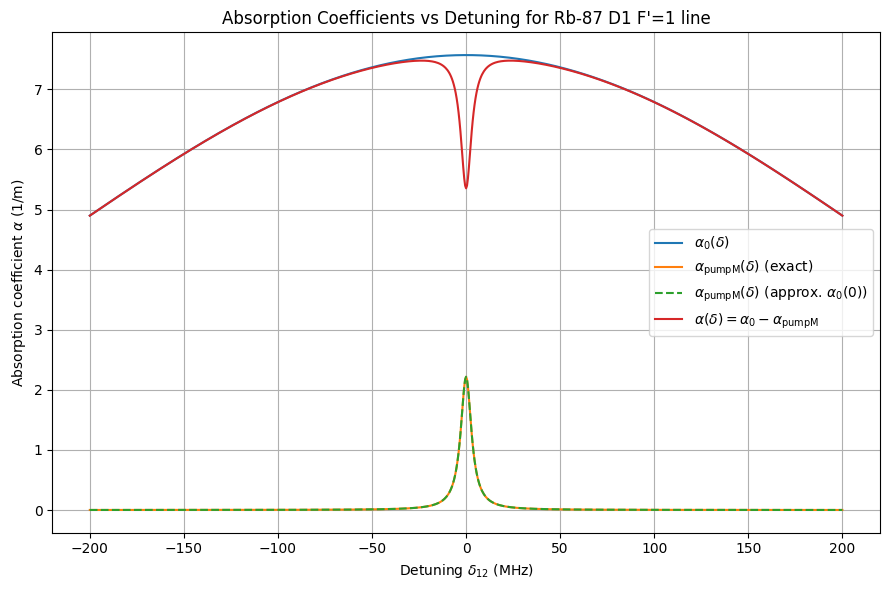

K_mSAS = 0.292893
Γ_mSAS = 6.941 MHz
α₀(0) = 7.571e+00 1/m


In [6]:
# in this visualization, the use of alpha_0(delta) and the delta->0 (alpha_0(0)) approximation is compared

# Detuning range (MHz → Hz)
delta_MHz = np.linspace(-200, 200, 801)
delta_Hz = delta_MHz * 1e6

# Compute α₀(δ)
alpha0_vals = compute_alpha0_numeric(delta_Hz, N, sigma_D11_0, u, lambda_D11, Gamma_D1)

# α₀(0) for approximation
alpha0_0 = np.interp(0.0, delta_Hz, alpha0_vals)

# Compute pump modification
alpha_pumpM_exact, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals, delta_Hz, I_pu_D1, I_sat_D11, Gamma_D1)
alpha_pumpM_approx = alpha0_0 * K_mSAS * L(delta_Hz, Gamma_mSAS)

# Final α(δ)
alpha_total_exact = alpha0_vals - alpha_pumpM_exact
alpha_total_approx = alpha0_vals - alpha_pumpM_approx

# Plot
plt.figure(figsize=(9,6))
plt.plot(delta_MHz, alpha0_vals, label=r'$\alpha_0(\delta)$')
plt.plot(delta_MHz, alpha_pumpM_exact, label=r'$\alpha_{\mathrm{pumpM}}(\delta)$ (exact)')
plt.plot(delta_MHz, alpha_pumpM_approx, '--', label=r'$\alpha_{\mathrm{pumpM}}(\delta)$ (approx. $\alpha_0(0)$)')
plt.plot(delta_MHz, alpha_total_exact, label=r'$\alpha(\delta) = \alpha_0 - \alpha_{\mathrm{pumpM}}$')
plt.xlabel(r'Detuning $\delta_{12}$ (MHz)')
plt.ylabel(r'Absorption coefficient $\alpha$ (1/m)')
plt.title("Absorption Coefficients vs Detuning for Rb-87 D1 F'=1 line")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"K_mSAS = {K_mSAS:.6f}")
print(f"Γ_mSAS = {Gamma_mSAS/1e6:.3f} MHz")
print(f"α₀(0) = {alpha0_0:.3e} 1/m")


### D1 to F'=1 and F'=2

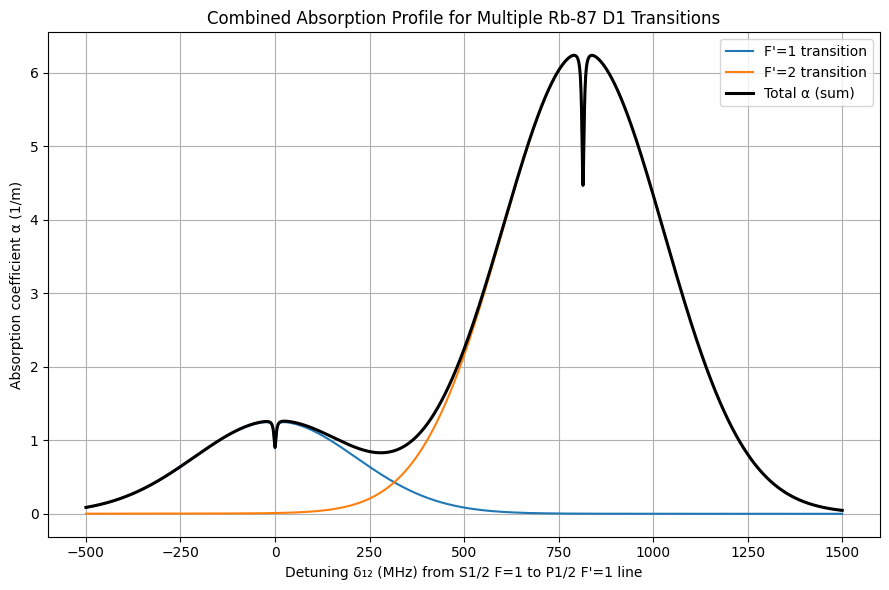

In [7]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma": Gamma_D1, "I_sat": I_sat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma": Gamma_D1, "I_sat": I_sat_D12, "label": "F'=2"},
]
transitions_ref_D1 = transitions.copy()

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)
plt.figure(figsize=(9,6))

zero_f = transitions[0]["f0"]
for tr in transitions:
    delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
    alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"], v_max_factor=7.0, n_v=20001)
    alpha_pumpM, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals, delta_shifted_Hz, I_pu_D1, tr["I_sat"], tr["Gamma"])
    alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpM)
    alpha_total += alpha_vals

    plt.plot(delta_MHz, alpha_vals, label=fr"{tr['label']} transition")

# Plot summed absorption
plt.plot(delta_MHz, alpha_total, 'k', linewidth=2.2, label="Total α (sum)")

plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P1/2 F'=1 line")
plt.ylabel(r'Absorption coefficient α (1/m)')
plt.title('Combined Absorption Profile for Multiple Rb-87 D1 Transitions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### D2

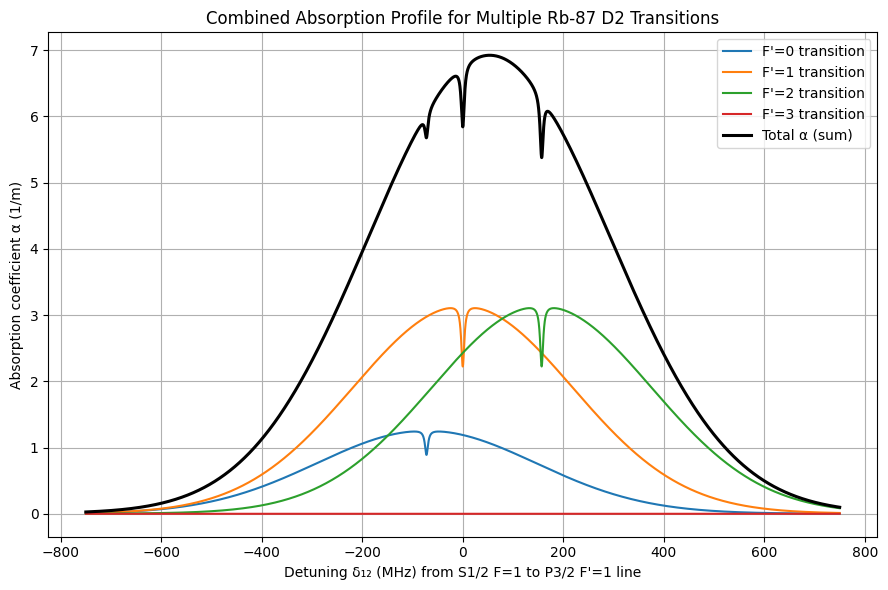

In [8]:
# Detuning range
delta_MHz = np.linspace(-750, 750, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D2_10, "f0": f_D20, "sigma0": sigma_D20_0, "lambda0": lambda_D20, "Gamma": Gamma_D2, "I_sat": I_sat_D20, "label": "F'=0"},
    {"strength":S_coeff_D2_11, "f0": f_D21, "sigma0": sigma_D21_0, "lambda0": lambda_D21, "Gamma": Gamma_D2, "I_sat": I_sat_D21, "label": "F'=1"},
    {"strength":S_coeff_D2_12, "f0": f_D22, "sigma0": sigma_D22_0, "lambda0": lambda_D22, "Gamma": Gamma_D2, "I_sat": I_sat_D22, "label": "F'=2"},
    {"strength":0, "f0": f_D23, "sigma0": sigma_D23_0, "lambda0": lambda_D23, "Gamma": Gamma_D2, "I_sat": I_sat_D23, "label": "F'=3"},
]
transitions_ref_D2 = transitions.copy()

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)
plt.figure(figsize=(9,6))

zero_f = transitions[1]["f0"]
for tr in transitions:
    delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
    alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"])
    alpha_pumpM, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals, delta_shifted_Hz, I_pu_D2, tr["I_sat"], tr["Gamma"])
    alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpM)
    alpha_total += alpha_vals

    plt.plot(delta_MHz, alpha_vals, label=fr"{tr['label']} transition")

# Plot summed absorption
plt.plot(delta_MHz, alpha_total, 'k', linewidth=2.2, label="Total α (sum)")

plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P3/2 F'=1 line")
plt.ylabel(r'Absorption coefficient α (1/m)')
plt.title('Combined Absorption Profile for Multiple Rb-87 D2 Transitions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### bSAS D1 

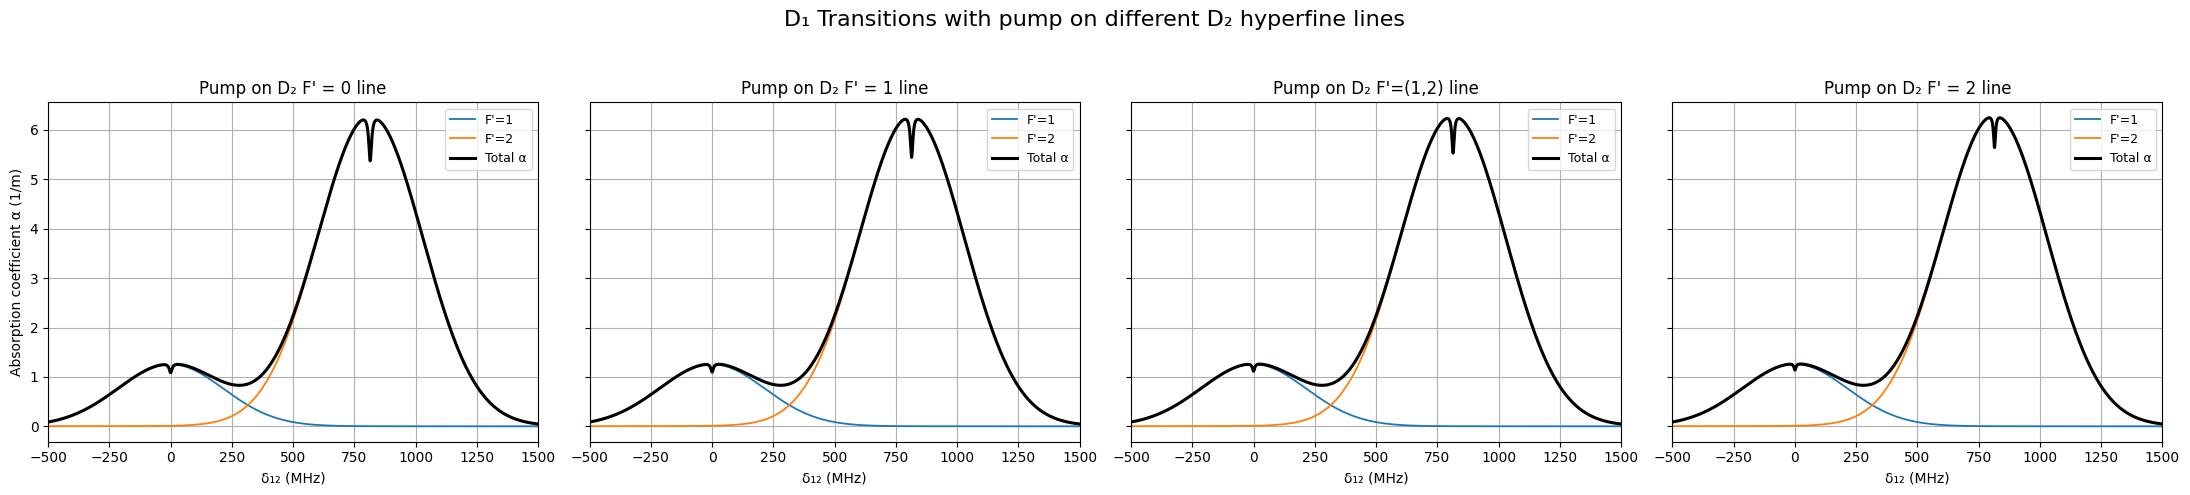

In [9]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6
delta_13 = 0.0 # pump in resonance

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma": Gamma_D1, "I_sat": I_sat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma": Gamma_D1, "I_sat": I_sat_D12, "label": "F'=2"},
]

# --- 1×4 comparison: pump on D2 F'=0,1,2,3 --------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
pump_labels = [r"F' = 0", r"F' = 1", r"F'=(1,2)", r"F' = 2"]
pump_lambdas = [lambda_D20, lambda_D21, ((1/lambda_D21 + 1/lambda_D22)/2)**(-1),lambda_D22]
Gamma_3 = [Gamma_D20, Gamma_D21, (Gamma_D21 + Gamma_D22)/2, Gamma_D22] # use average linewidth for (1,2) case as approximation

for ax, Gamma_3_val, lambda_3, lbl in zip(axes, Gamma_3, pump_lambdas, pump_labels):
    alpha_total = np.zeros_like(delta_Hz)
    zero_f = transitions[0]["f0"]
    
    for tr in transitions:
        # Compute α for each transition and sum
        delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
        alpha0_vals = compute_alpha0_numeric(
            delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"]
        )

        # wavelength mismatch between probe and pump
        epsilon = tr["lambda0"] / lambda_3 - 1

        # use corrected compute_pumpB (the fixed version)
        alpha_pumpB, K_bSAS, Gamma_bSAS = compute_pumpB(
            alpha0_vals, delta_shifted_Hz, delta_13,
            I_pu_D1, tr["I_sat"], tr["Gamma"], Gamma_3_val, epsilon
        )

        alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpB)
        alpha_total += alpha_vals

        ax.plot(delta_MHz, alpha_vals, lw=1.3, label=fr"{tr['label']}")

    # total absorption (black thick line)
    ax.plot(delta_MHz, alpha_total, "k", lw=2.2, label="Total α")

    ax.set_title(fr"Pump on D₂ {lbl} line")
    ax.set_xlabel(r"δ₁₂ (MHz)")
    ax.grid(True)
    ax.legend(fontsize=9)
    ax.set_xlim(-500, 1500)  # zoom region where lamb dip visible

axes[0].set_ylabel(r"Absorption coefficient α (1/m)")
fig.suptitle("D₁ Transitions with pump on different D₂ hyperfine lines", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### bSAS D1 with pump detuning

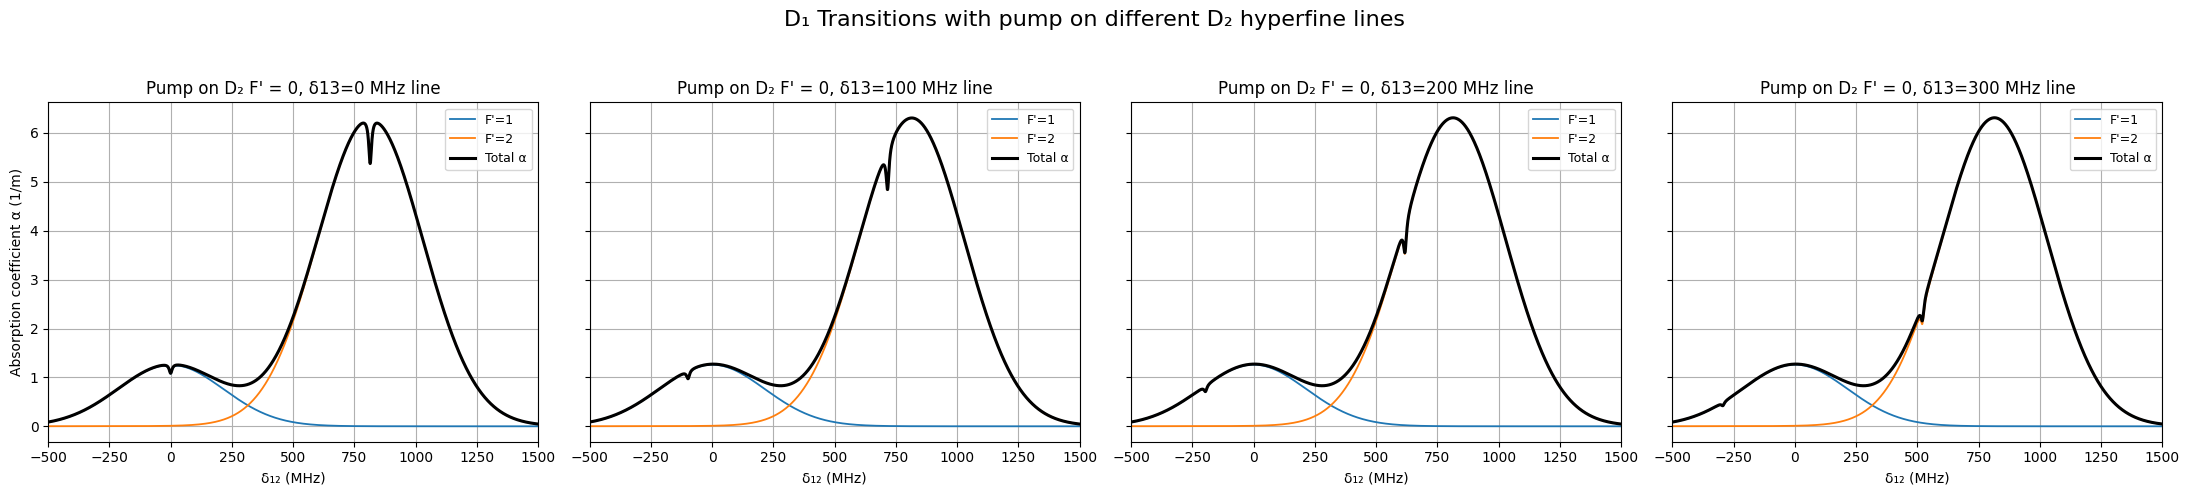

In [10]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6
delta_13 = [0, 100e6, 200e6, 300e6] # pump in resonance

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma": Gamma_D1, "I_sat": I_sat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma": Gamma_D1, "I_sat": I_sat_D12, "label": "F'=2"},
]

# --- 1×4 comparison: pump on D2 F'=0,1,2,3 --------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
pump_labels = [fr"F' = 0, δ13={d_13/1e6:.0f} MHz" for d_13 in delta_13]
pump_lambdas = [lambda_D20, lambda_D20, lambda_D20,lambda_D20]
Gamma_3 = [Gamma_D20, Gamma_D20, Gamma_D20, Gamma_D20] # use average linewidth for (1,2) case as approximation

for ax, d_13, Gamma_3_val, lambda_3, lbl in zip(axes, delta_13, Gamma_3, pump_lambdas, pump_labels):
    alpha_total = np.zeros_like(delta_Hz)
    zero_f = transitions[0]["f0"]
    
    for tr in transitions:
        # Compute α for each transition and sum
        delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
        alpha0_vals = compute_alpha0_numeric(
            delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"]
        )

        # wavelength mismatch between probe and pump
        epsilon = tr["lambda0"] / lambda_3 - 1

        # use corrected compute_pumpB (the fixed version)
        alpha_pumpB, K_bSAS, Gamma_bSAS = compute_pumpB(
            alpha0_vals, delta_shifted_Hz, d_13,
            I_pu_D1, tr["I_sat"], tr["Gamma"], Gamma_3_val, epsilon
        )

        alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpB)
        alpha_total += alpha_vals

        ax.plot(delta_MHz, alpha_vals, lw=1.3, label=fr"{tr['label']}")

    # total absorption (black thick line)
    ax.plot(delta_MHz, alpha_total, "k", lw=2.2, label="Total α")

    ax.set_title(fr"Pump on D₂ {lbl} line")
    ax.set_xlabel(r"δ₁₂ (MHz)")
    ax.grid(True)
    ax.legend(fontsize=9)
    ax.set_xlim(-500, 1500)  # zoom region where lamb dip visible

axes[0].set_ylabel(r"Absorption coefficient α (1/m)")
fig.suptitle("D₁ Transitions with pump on different D₂ hyperfine lines", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


# With line broadening

## Constants

In [11]:
# Saturation and pump intensities
I_psat_D11 = I_sat_D11 * (1+Gamma_tr/(Gamma_D11+Gamma_D11_d))/(1+Gamma_D11_d/(2*Gamma_tr))
I_psat_D12 = I_sat_D12 * (1+Gamma_tr/(Gamma_D12+Gamma_D12_d))/(1+Gamma_D12_d/(2*Gamma_tr))
I_pu_D1 = I_psat_D11  # set equal I_sat_D11
print(f"I_pu_D1 = {I_pu_D1/10:.2f} mW/cm^2 I_psat_D11 = {I_psat_D11/10:.2f} mW/cm^2")

I_psat_D20 = I_sat_D20 * (1+Gamma_tr/(Gamma_D20+Gamma_D20_d))/(1+Gamma_D20_d/(2*Gamma_tr))
I_psat_D21 = I_sat_D21 * (1+Gamma_tr/(Gamma_D21+Gamma_D21_d))/(1+Gamma_D21_d/(2*Gamma_tr))
I_psat_D22 = I_sat_D22 * (1+Gamma_tr/(Gamma_D22+Gamma_D22_d))/(1+Gamma_D22_d/(2*Gamma_tr))
I_psat_D23 = I_sat_D23 * (1+Gamma_tr/(Gamma_D23+Gamma_D23_d))/(1+Gamma_D23_d/(2*Gamma_tr))
I_pu_D2 = I_psat_D21  # set equal I_sat_D21
print(f"I_pu_D2 = {I_pu_D2/10:.2f} mW/cm^2 I_psat_D21 = {I_psat_D21/10:.2f} mW/cm^2")

I_pu_D1 = 0.04 mW/cm^2 I_psat_D11 = 0.04 mW/cm^2
I_pu_D2 = 0.17 mW/cm^2 I_psat_D21 = 0.17 mW/cm^2


## Algorithm

### mSAS

In [12]:
def compute_pumpM_tilde(alpha0_delta, delta_array_Hz, I_pu, I_psat, Gamma2_tilde):
    """
    Computes α_pumpM(δ) = α₀(δ) * K_mSAS_tilde * L_tilde(δ, Γ_mSAS).
    """
    K_mSAS_tilde = 1 - (1 + I_pu / I_psat)**(-0.5)
    Gamma_mSAS_tilde = (Gamma2_tilde / 2) * (1 + np.sqrt(1 + I_pu / I_psat))
    L_vals = L(delta_array_Hz, Gamma_mSAS_tilde)
    alpha_pumpM = alpha0_delta * K_mSAS_tilde * L_vals
    return alpha_pumpM, K_mSAS_tilde, Gamma_mSAS_tilde

### bSAS

In [13]:
def L_tilde(delta, Gamma_tilde, I_pu, I_psat):
    """Modified Lorentzian lineshape considering transit-time broadening."""
    factor = np.sqrt(1 + I_pu / I_psat)
    Gamma_effective = Gamma_tilde * factor
    return ((Gamma_effective**2) / 4) / (delta**2 + (Gamma_effective**2) / 4)

def compute_pumpB_tilde(alpha0_delta, delta_array_Hz, delta_13, I_pu, I_psat, Gamma2_tilde, Gamma3_tilde, Gamma3_d, Gamma_tr, epsilon):
    """
    Computes α_pumpB(δ) = α₀(δ) * K_bSAS * L(δ, Γ_bSAS).
    """
    temp = (1+I_pu/I_psat)**(0.5)
    K_bSAS_tilde = (1+Gamma3_d/Gamma_tr)/(1+Gamma3_d/(2*Gamma_tr)) * (I_pu/I_psat)/(temp*(Gamma2_tilde/Gamma3_tilde * (1+epsilon) + temp))
    Gamma_bSAS_tilde = Gamma2_tilde + Gamma3_tilde/(1+epsilon) * temp
    L_vals_tilde = L_tilde(delta_array_Hz + delta_13/(1+epsilon), Gamma_bSAS_tilde, I_pu, I_psat)
    alpha_pumpB = alpha0_delta/2 * K_bSAS_tilde * L_vals_tilde
    return alpha_pumpB, K_bSAS_tilde, Gamma_bSAS_tilde

## Visualization

### D1 mSAS

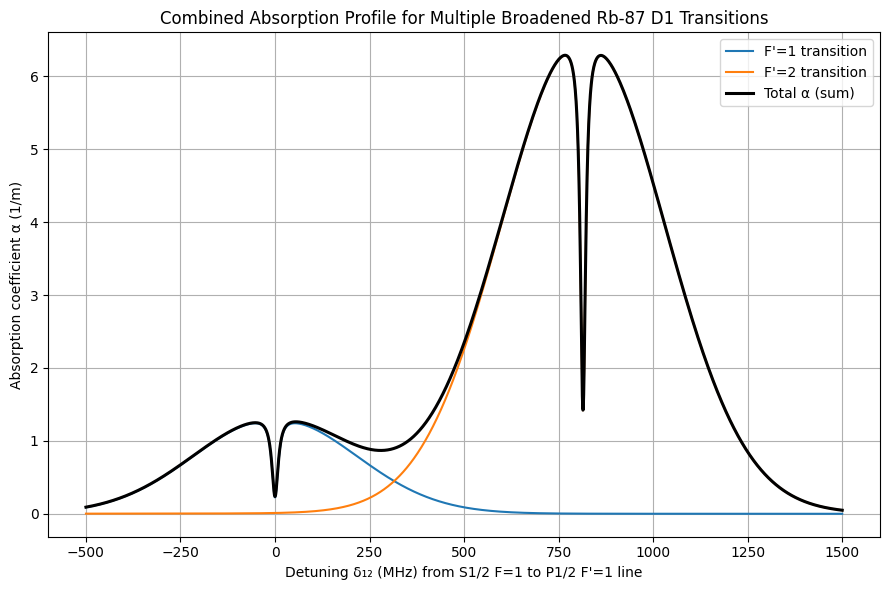

Supposed peak height: 7.6523258682698305


In [ ]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
# or some reason sigma0 is the same but the linewidths are modified
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma_tilde": Gamma_D11+Gamma_D11_d+2*Gamma_tr, "I_psat": I_psat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma_tilde": Gamma_D12+Gamma_D12_d+2*Gamma_tr, "I_psat": I_psat_D12, "label": "F'=2"},
]

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)
plt.figure(figsize=(9,6))

def compute_alpha0_numeric_1(delta_array_Hz, N, sigma0, u, lambda0, Gamma2,
                           v_max_factor=7.0, n_v=20001):
    """
    Numerical integration for α₀(δ):
        α₀ = Nσ₀ ∫ f_D(v) L(δ - k_pr*v, Γ₂) dv

    the -infty to infty integral is  approximated as  -v_max_factor * u to v_max_factor * u
    The integral is numerically solved with trapz (n_v is the number of trapezoidal elements) 
    """
    k_freq = 1.0 / lambda0  # in cycles/m instead  of rad/m, because delta is in Hz
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    dv = v[1] - v[0]
    
    alpha0 = np.zeros_like(delta_array_Hz)
    for i, delta in enumerate(delta_array_Hz):
        alpha0[i] = N * sigma0 * f_D(delta/k_freq, u) * np.pi * Gamma2 / (2 * k_freq)
    print(f_D(0,u) * np.pi**2)
    return alpha0

zero_f = transitions[0]["f0"]
i=0
for tr in transitions:
    i+=1
    delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
    alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma_tilde"], v_max_factor=5.0, n_v=2001)
    # alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, transitions_ref_D1[i-1]["sigma0"], u, tr["lambda0"], transitions_ref_D1[i-1]["Gamma"])
    # alpha0_vals = compute_alpha0_numeric_1(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma_tilde"])
    # alpha0_vals = compute_alpha0_numeric_1(delta_shifted_Hz, N, transitions_ref_D1[i-1]["sigma0"], u, tr["lambda0"], tr["Gamma_tilde"])
    alpha_pumpM, K_mSAS_tilde, Gamma_mSAS_tilde = compute_pumpM_tilde(alpha0_vals, delta_shifted_Hz, I_pu_D1, tr["I_psat"], tr["Gamma_tilde"])
    alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpM)
    alpha_total += alpha_vals

    plt.plot(delta_MHz, alpha_vals, label=fr"{tr['label']} transition")

# Plot summed absorption
plt.plot(delta_MHz, alpha_total, 'k', linewidth=2.2, label="Total α (sum)")

plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P1/2 F'=1 line")
plt.ylabel(r'Absorption coefficient α (1/m)')
plt.title('Combined Absorption Profile for Multiple Broadened Rb-87 D1 Transitions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Supposed peak height: {N*3*lambda_D11**2/(2*np.pi) * f_D(0,u) * ( np.pi * Gamma_D1 / (2/lambda_D11) )  / 3}")


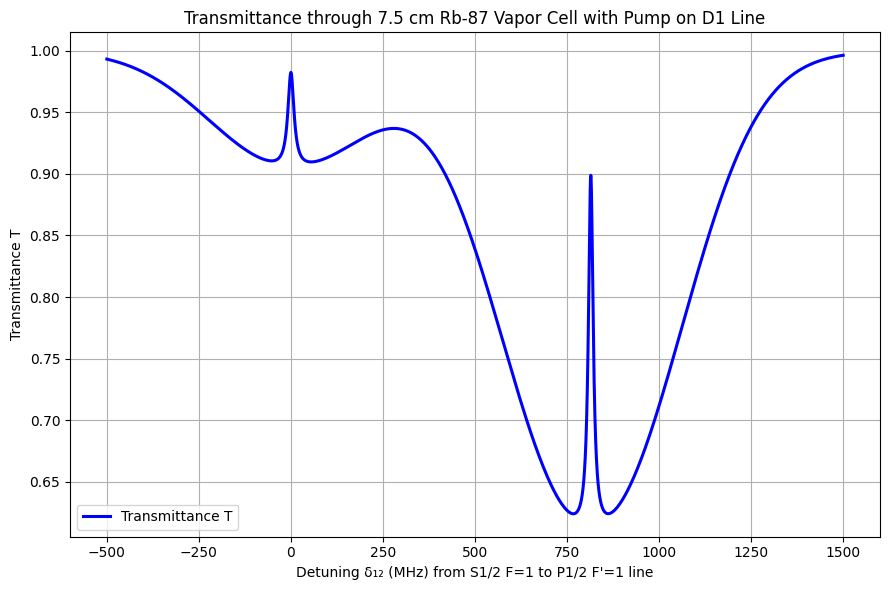

In [15]:
# Transmittance calculation
L_cell = 75e-3  # 75 mm 
T_total = np.exp(-alpha_total * L_cell)
plt.figure(figsize=(9,6))
plt.plot(delta_MHz, T_total, 'b', linewidth=2.2, label="Transmittance T")
plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P1/2 F'=1 line")
plt.ylabel(r'Transmittance T')
plt.title(f'Transmittance through {L_cell*100:.1f} cm Rb-87 Vapor Cell with Pump on D1 Line')
# plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

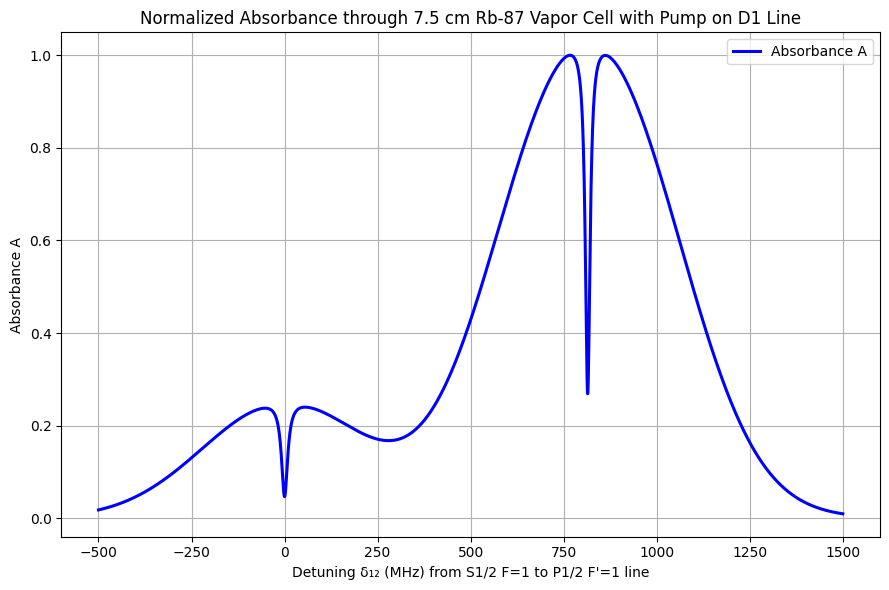

In [16]:
# Absorbance calculation
L_cell = 75e-3  # 75 mm 
A_total = 1-np.exp(-alpha_total * L_cell)
A_total = A_total / np.max(A_total)  # normalize to max 1 for visualization
plt.figure(figsize=(9,6))
plt.plot(delta_MHz, A_total, 'b', linewidth=2.2, label="Absorbance A")
plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P1/2 F'=1 line")
plt.ylabel(r'Absorbance A')
plt.title(f'Normalized Absorbance through {L_cell*100:.1f} cm Rb-87 Vapor Cell with Pump on D1 Line')
# plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### D2 mSAS

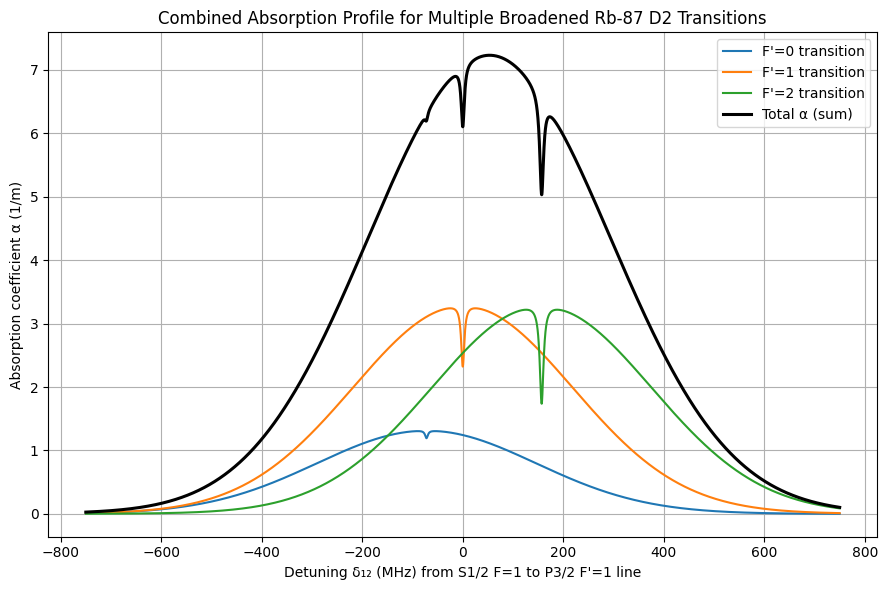

In [17]:
# Detuning range
delta_MHz = np.linspace(-750, 750, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D2_10, "f0": f_D20, "sigma0": sigma_D20_0, "lambda0": lambda_D20, "Gamma_tilde": Gamma_D20+Gamma_D20_d+2*Gamma_tr, "I_psat": I_psat_D20, "label": "F'=0"},
    {"strength":S_coeff_D2_11, "f0": f_D21, "sigma0": sigma_D21_0, "lambda0": lambda_D21, "Gamma_tilde": Gamma_D21+Gamma_D21_d+2*Gamma_tr, "I_psat": I_psat_D21, "label": "F'=1"},
    {"strength":S_coeff_D2_12, "f0": f_D22, "sigma0": sigma_D22_0, "lambda0": lambda_D22, "Gamma_tilde": Gamma_D22+Gamma_D22_d+2*Gamma_tr, "I_psat": I_psat_D22, "label": "F'=2"},
    # {"strength":0, "f0": f_D23, "sigma0": sigma_D23_0, "lambda0": lambda_D23, "Gamma_tilde": Gamma_D23+Gamma_D23_d+2*Gamma_tr, "I_psat": I_psat_D23, "label": "F'=3"},
]

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)
plt.figure(figsize=(9,6))

zero_f = transitions[1]["f0"]
i=0
for tr in transitions:
    i+=1
    delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
    # alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, transitions_ref_D2[i-1]["sigma0"], u, tr["lambda0"], transitions_ref_D2[i-1]["Gamma"])
    alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma_tilde"])
    alpha_pumpM, K_mSAS, Gamma_mSAS = compute_pumpM_tilde(alpha0_vals, delta_shifted_Hz, I_pu_D2, tr["I_psat"], tr["Gamma_tilde"])
    alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpM)
    alpha_total += alpha_vals

    plt.plot(delta_MHz, alpha_vals, label=fr"{tr['label']} transition")

# Plot summed absorption
plt.plot(delta_MHz, alpha_total, 'k', linewidth=2.2, label="Total α (sum)")

plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P3/2 F'=1 line")
plt.ylabel(r'Absorption coefficient α (1/m)')
plt.title('Combined Absorption Profile for Multiple Broadened Rb-87 D2 Transitions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


D1 bSAS

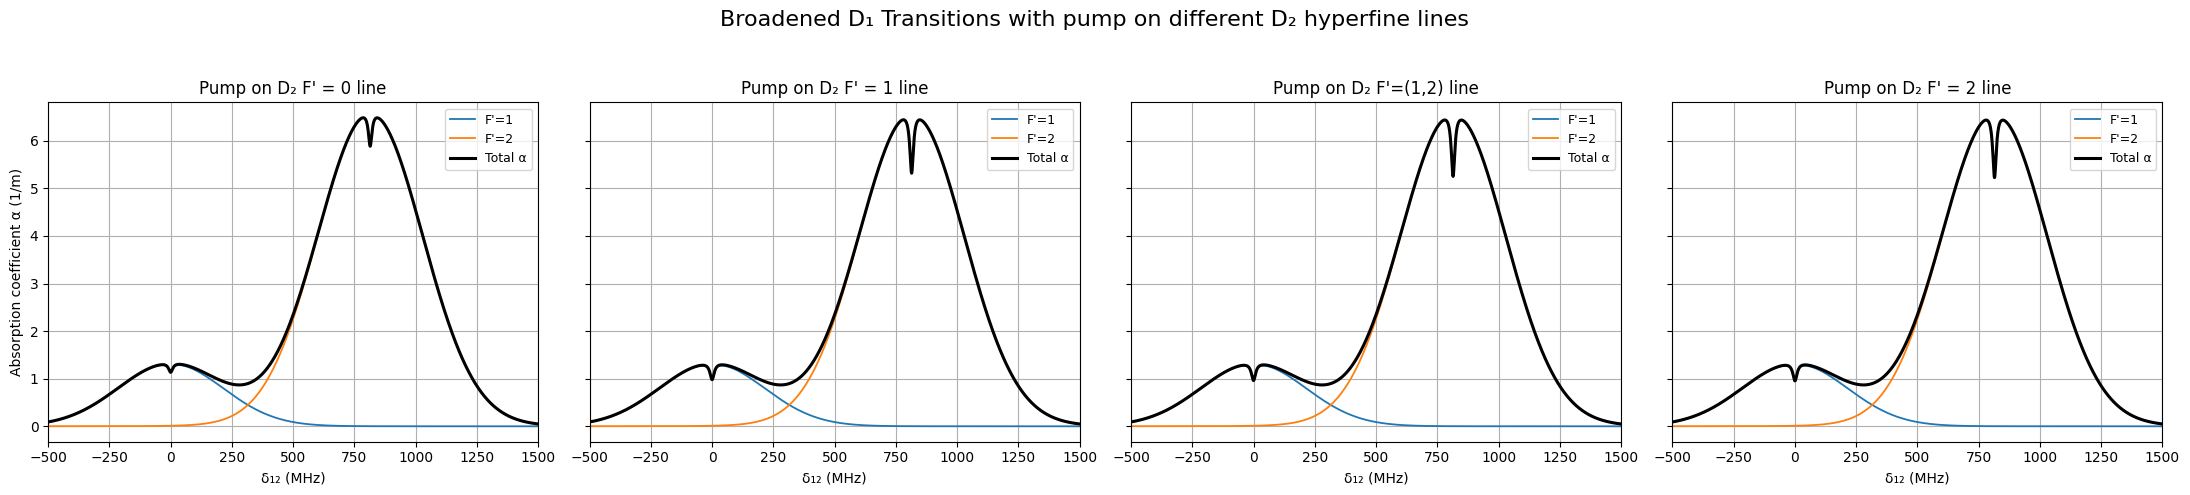

In [18]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6
delta_13 = 0.0 # pump in resonance

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma_tilde": Gamma_D11+Gamma_D11_d+2*Gamma_tr, "I_psat": I_psat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma_tilde": Gamma_D12+Gamma_D12_d+2*Gamma_tr, "I_psat": I_psat_D12, "label": "F'=2"},
]

# --- 1×4 comparison: pump on D2 F'=0,1,2,3 --------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
pump_labels = [r"F' = 0", r"F' = 1", r"F'=(1,2)", r"F' = 2"]
pump_lambdas = [lambda_D20, lambda_D21, ((1/lambda_D21 + 1/lambda_D22)/2)**(-1),lambda_D22]
Gamma_3 = [Gamma_D20, Gamma_D21, (Gamma_D21 + Gamma_D22)/2, Gamma_D22] # use average linewidth for (1,2) case as approximation
Gamma_3_d = [Gamma_D20_d, Gamma_D21_d, (Gamma_D21_d + Gamma_D22_d)/2, Gamma_D22_d] # use average linewidth for (1,2) case as approximation

for ax, Gamma_3_d_val, Gamma_3_val, lambda_3, lbl in zip(axes, Gamma_3_d, Gamma_3, pump_lambdas, pump_labels):
    alpha_total = np.zeros_like(delta_Hz)
    zero_f = transitions[0]["f0"]
    i=0
    for tr in transitions:
        i+=1
        # Compute α for each transition and sum
        delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
        # alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, transitions_ref_D1[i-1]["sigma0"], u, tr["lambda0"], transitions_ref_D1[i-1]["Gamma"])
        alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma_tilde"])

        # wavelength mismatch between probe and pump
        epsilon = tr["lambda0"] / lambda_3 - 1

        # use corrected compute_pumpB (the fixed version)
        alpha_pumpB, K_bSAS, Gamma_bSAS = compute_pumpB_tilde(
            alpha0_vals, delta_shifted_Hz, delta_13,
            I_pu_D1, tr["I_psat"], tr["Gamma_tilde"], 
            Gamma_3_val+Gamma_3_d_val+2*Gamma_tr, Gamma_3_d_val, Gamma_tr, epsilon
        )

        alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpB)
        alpha_total += alpha_vals

        ax.plot(delta_MHz, alpha_vals, lw=1.3, label=fr"{tr['label']}")

    # total absorption (black thick line)
    ax.plot(delta_MHz, alpha_total, "k", lw=2.2, label="Total α")

    ax.set_title(fr"Pump on D₂ {lbl} line")
    ax.set_xlabel(r"δ₁₂ (MHz)")
    ax.grid(True)
    ax.legend(fontsize=9)
    ax.set_xlim(-500, 1500)  # zoom region where lamb dip visible

axes[0].set_ylabel(r"Absorption coefficient α (1/m)")
fig.suptitle("Broadened D₁ Transitions with pump on different D₂ hyperfine lines", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
